**Table of contents**<a id='toc0_'></a>    
- [Cy5 molecule and transitions](#toc1_)    
  - [Cy5 molecule](#toc1_1_)    
    - [Trans Cy5](#toc1_1_1_)    
    - [Bleached Cy5 (1)](#toc1_1_2_)    
    - [Bleached Cy5 (2)](#toc1_1_3_)    
    - [Cis Cy5](#toc1_1_4_)    
    - [Cy5-SH](#toc1_1_5_)    
    - [Cy5 R](#toc1_1_6_)    
  - [Cy5 transitions](#toc1_2_)    
    - [Image preparation](#toc1_2_1_)    
    - [Jablonski/Transition diagram](#toc1_2_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Cy5 molecule and transitions](#toc0_)

In [1]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdMolTransforms

saving_at = r"D:\python_output\Chapter_I\0_1_introduction_figure"

## <a id='toc1_1_'></a>[Cy5 molecule](#toc0_)

### <a id='toc1_1_1_'></a>[Trans Cy5](#toc0_)

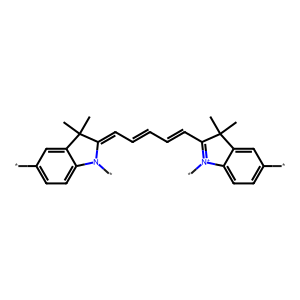

In [2]:
cy5 = Chem.MolFromSmiles(
    r"C1=C(*)C=C2C(C)(C)C(=CC=CC=CC3=[N+](*)C4=CC=C(*)C=C4C(C)(C)3)N(*)C2=C1"
)
Draw.MolToImage(cy5)

### <a id='toc1_1_2_'></a>[Bleached Cy5 (1)](#toc0_)

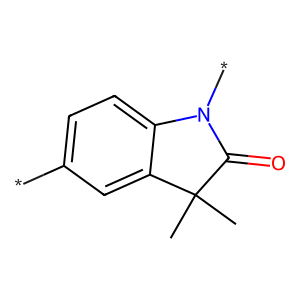

In [3]:
cy5_B_1 = Chem.MolFromSmiles(r"C1(*)=CC=C2N(*)C(=O)C(C)(C)C2=C1")
Draw.MolToImage(cy5_B_1)

### <a id='toc1_1_3_'></a>[Bleached Cy5 (2)](#toc0_)

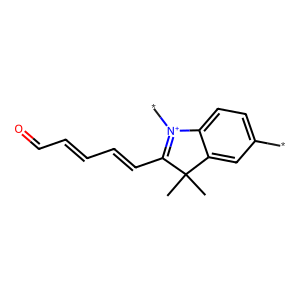

In [4]:
cy5_B_2 = Chem.MolFromSmiles(r"O=CC=CC=CC3C(C)(C)C4=CC(*)=CC=C4[N+]=3(*)")
Draw.MolToImage(cy5_B_2)

### <a id='toc1_1_4_'></a>[Cis Cy5](#toc0_)

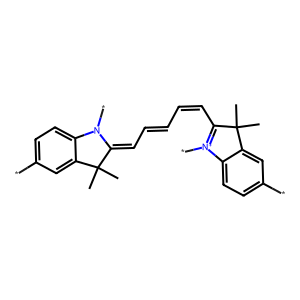

In [5]:
cy5_cis = Chem.MolFromSmiles(
    r"C1(*)=CC=C2N(*)C(=CC=C/C=C\C3=[N+](*)C4=CC=C(*)C=C4C(C)(C)3)C(C)(C)C2=C1"
)
Draw.MolToImage(cy5_cis)

### <a id='toc1_1_5_'></a>[Cy5-SH](#toc0_)

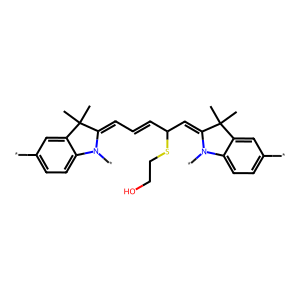

In [6]:
cy5_sh = Chem.MolFromSmiles(
    r"C1(*)=CC=C2N(*)C(=CC(SCCO)C=CC=C3C(C)(C)C4=CC(*)=CC=C4N3(*))C(C)(C)C2=C1"
)
Draw.MolToImage(cy5_sh)

### <a id='toc1_1_6_'></a>[Cy5 R](#toc0_)

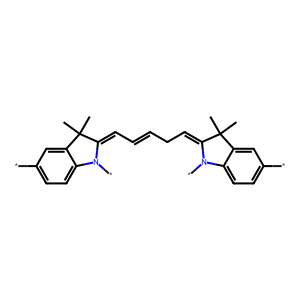

: 

In [ ]:
cy5_r = Chem.MolFromSmiles(
    r"C1(*)=CC=C2N(*)C(=CCC=CC=C3C(C)(C)C4=CC(*)=CC=C4N3(*))C(C)(C)C2=C1"
)
Draw.MolToImage(cy5_r)

## <a id='toc1_2_'></a>[Cy5 transitions](#toc0_)

### <a id='toc1_2_1_'></a>[Image preparation](#toc0_)

In [55]:
def rotation_matrix_z(degrees):
    radians = np.radians(degrees)
    cos_theta = np.cos(radians)
    sin_theta = np.sin(radians)

    matrix = np.array(
        [
            [cos_theta, -sin_theta, 0, 0],
            [sin_theta, cos_theta, 0, 0],
            [0, 0, 1, 0],
            [0, 0, 0, 1],
        ]
    )

    return matrix


def mol_to_img(mol, size=300, degrees=0):
    AllChem.Compute2DCoords(mol)
    # rdDepictor.SetPreferCoordGen(True)
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(size, size)
    drawer.drawOptions().useBWAtomPalette()
    drawer.drawOptions().setBackgroundColour((1, 1, 1, 0))
    rotate_matrix = rotation_matrix_z(degrees)
    rdMolTransforms.TransformConformer(mol.GetConformer(0), rotate_matrix)
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()

    img = Draw._drawerToImage(drawer)

    return img


cy5_img = mol_to_img(cy5, size=500, degrees=0)
cy5_B_1_img = mol_to_img(cy5_B_1, size=200, degrees=0)
cy5_B_2_img = mol_to_img(cy5_B_2, size=300, degrees=40)
cy5_cis_img = mol_to_img(cy5_cis, size=450, degrees=0)
cy5_sh_img = mol_to_img(cy5_sh, size=450, degrees=0)
cy5_r_img = mol_to_img(cy5_r, size=450, degrees=0)

### <a id='toc1_2_2_'></a>[Jablonski/Transition diagram](#toc0_)

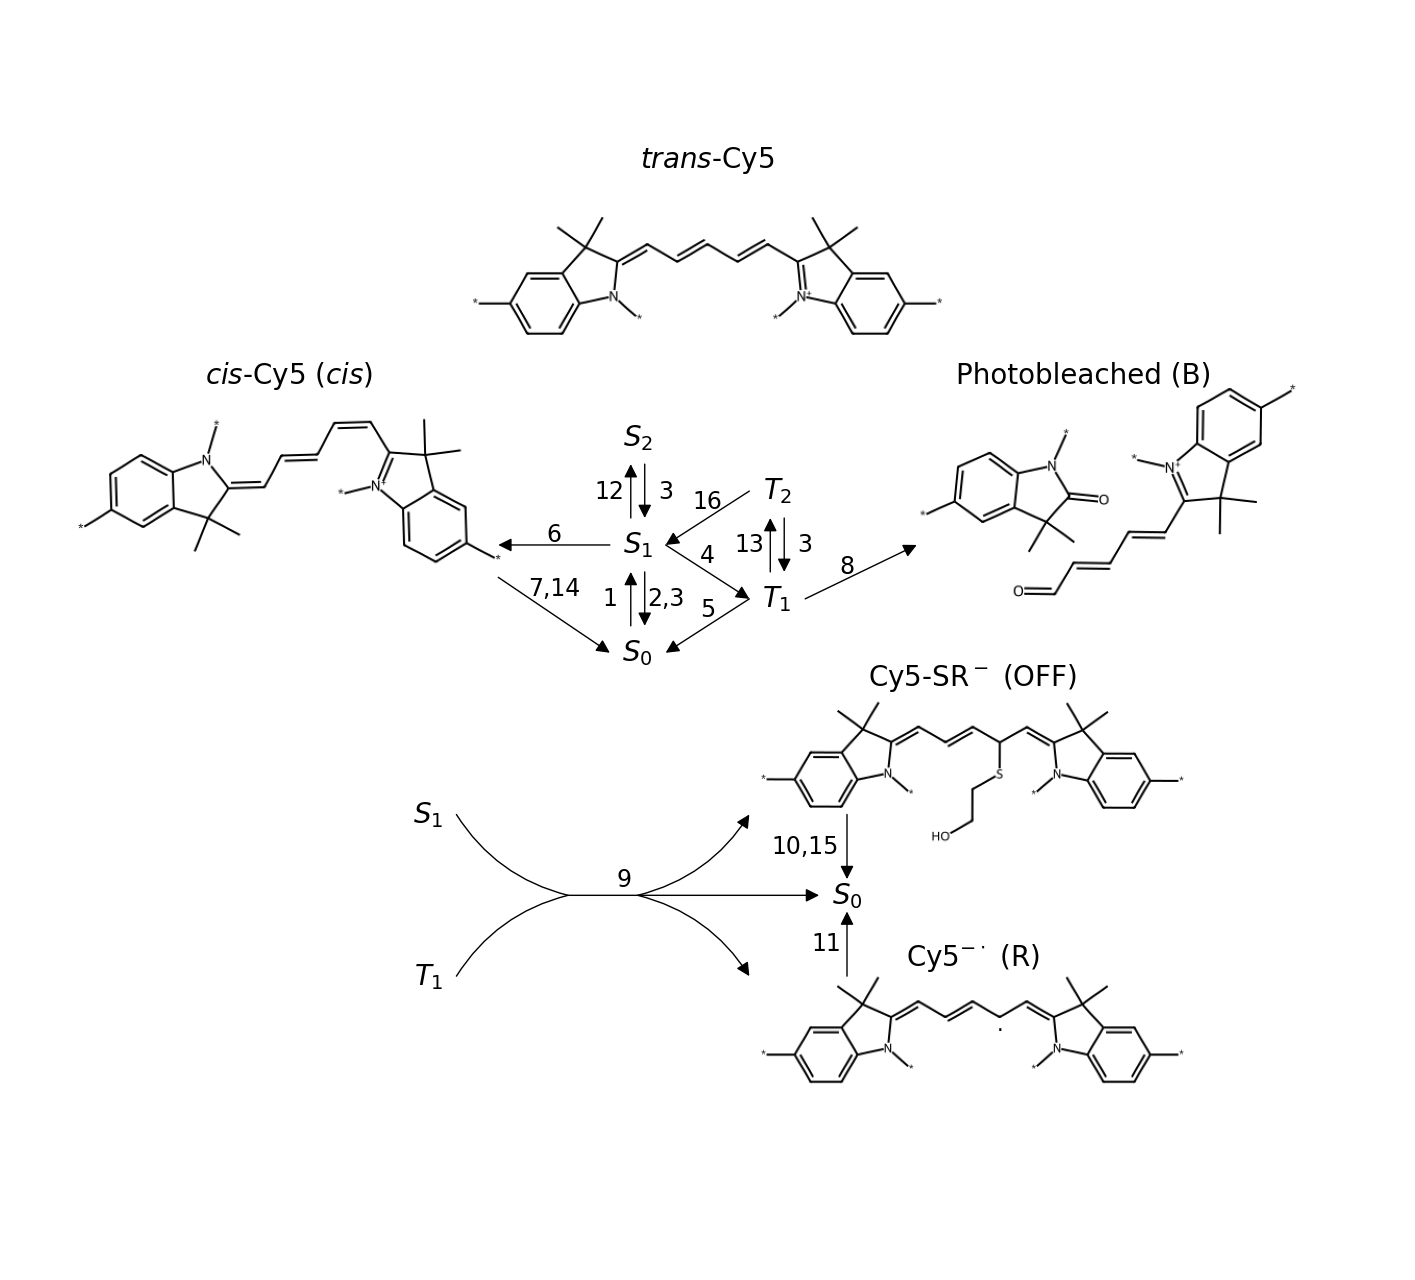

In [69]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

fig, ax = plt.subplots(figsize=(18, 14))
ax.axis("off")

# cy5
img = OffsetImage(cy5_img, zoom=0.75)
img = AnnotationBbox(img, (0.5, 0.8), frameon=False)
ax.add_artist(img)
ax.text(s=r"$\it{trans}$-Cy5", x=0.5, y=0.9, fontsize=20, ha="center")

# cy5_B
img = OffsetImage(cy5_B_1_img, zoom=0.75)
img = AnnotationBbox(img, (0.72, 0.6), frameon=False)
ax.add_artist(img)
img = OffsetImage(cy5_B_2_img, zoom=0.75)
img = AnnotationBbox(img, (0.82, 0.6), frameon=False)
ax.add_artist(img)
ax.text(s="Photobleached (B)", x=0.77, y=0.7, fontsize=20, ha="center")

# cy5_cis
img = OffsetImage(cy5_cis_img, zoom=0.75)
img = AnnotationBbox(img, (0.2, 0.6), frameon=False)
ax.add_artist(img)
ax.text(s=r"$\it{cis}$-Cy5 ($\it{cis}$)", x=0.2, y=0.7, fontsize=20, ha="center")

# cy5_sh
img = OffsetImage(cy5_sh_img, zoom=0.75)
img = AnnotationBbox(img, (0.69, 0.34), frameon=False)
ax.add_artist(img)
ax.text(s=r"Cy5-SR$^-$ (OFF)", x=0.69, y=0.42, fontsize=20, ha="center")

# cy5_r
img = OffsetImage(cy5_r_img, zoom=0.75)
img = AnnotationBbox(img, (0.69, 0.10), frameon=False)
ax.add_artist(img)
ax.text(s=".", x=0.71, y=0.10, fontsize=15, ha="center")
ax.text(s=r"Cy5$^{-\cdot}$ (R)", x=0.69, y=0.16, fontsize=20, ha="center")

# photophysical states
ax.text(s=r"$S_{0}$", x=0.45, y=0.45, fontsize=20, ha="center", va="center")
ax.text(s=r"$S_{1}$", x=0.45, y=0.55, fontsize=20, ha="center", va="center")
ax.text(s=r"$S_{2}$", x=0.45, y=0.65, fontsize=20, ha="center", va="center")
ax.text(s=r"$T_{1}$", x=0.55, y=0.5, fontsize=20, ha="center", va="center")
ax.text(s=r"$T_{2}$", x=0.55, y=0.6, fontsize=20, ha="center", va="center")

prop = dict(
    arrowstyle="-|>, head_width=0.4, head_length=0.8",
    shrinkA=0,
    shrinkB=0,
    facecolor="black",
    edgecolor="black",
    lw=1,
)
# s0 to s1
ax.annotate("", xy=(0.445, 0.525), xytext=(0.445, 0.475), arrowprops=prop)
ax.text(s="1", x=0.43, y=0.5, fontsize=17, ha="center", va="center")
# s1 to s0
ax.annotate("", xy=(0.455, 0.475), xytext=(0.455, 0.525), arrowprops=prop)
ax.text(s="2,3", x=0.47, y=0.5, fontsize=17, ha="center", va="center")
# s1 to s2
ax.annotate("", xy=(0.445, 0.625), xytext=(0.445, 0.575), arrowprops=prop)
ax.text(s="12", x=0.43, y=0.6, fontsize=17, ha="center", va="center")
# s2 to s1
ax.annotate("", xy=(0.455, 0.575), xytext=(0.455, 0.625), arrowprops=prop)
ax.text(s="3", x=0.47, y=0.6, fontsize=17, ha="center", va="center")
# s1 to t1
ax.annotate("", xy=(0.53, 0.5), xytext=(0.47, 0.55), arrowprops=prop)
ax.text(s="4", x=0.5, y=0.54, fontsize=17, ha="center", va="center")
# t1 to t2
ax.annotate("", xy=(0.545, 0.575), xytext=(0.545, 0.525), arrowprops=prop)
ax.text(s="13", x=0.53, y=0.55, fontsize=17, ha="center", va="center")
# t2 to t1
ax.annotate("", xy=(0.555, 0.525), xytext=(0.555, 0.575), arrowprops=prop)
ax.text(s="3", x=0.57, y=0.55, fontsize=17, ha="center", va="center")
# t2 to s1
ax.annotate("", xy=(0.47, 0.55), xytext=(0.53, 0.6), arrowprops=prop)
ax.text(s="16", x=0.5, y=0.59, fontsize=17, ha="center", va="center")
# t1 to s0
ax.annotate("", xy=(0.47, 0.45), xytext=(0.53, 0.5), arrowprops=prop)
ax.text(s="5", x=0.5, y=0.49, fontsize=17, ha="center", va="center")
# t1 to bleached
ax.annotate("", xy=(0.65, 0.55), xytext=(0.57, 0.5), arrowprops=prop)
ax.text(s="8", x=0.6, y=0.53, fontsize=17, ha="center", va="center")
# s1 to cis
ax.annotate("", xy=(0.35, 0.55), xytext=(0.43, 0.55), arrowprops=prop)
ax.text(s="6", x=0.39, y=0.56, fontsize=17, ha="center", va="center")
# cis to s0
ax.annotate("", xy=(0.43, 0.45), xytext=(0.35, 0.52), arrowprops=prop)
ax.text(s="7,14", x=0.39, y=0.51, fontsize=17, ha="center", va="center")
# sh to s0
ax.annotate("", xy=(0.6, 0.24), xytext=(0.6, 0.3), arrowprops=prop)
ax.text(s="10,15", x=0.57, y=0.27, fontsize=17, ha="center", va="center")
# r to s0
ax.annotate("", xy=(0.6, 0.21), xytext=(0.6, 0.15), arrowprops=prop)
ax.text(s="11", x=0.585, y=0.18, fontsize=17, ha="center", va="center")

ax.text(s=r"$S_{1}$", x=0.3, y=0.3, fontsize=20, ha="center", va="center")
ax.text(s=r"$T_{1}$", x=0.3, y=0.15, fontsize=20, ha="center", va="center")
ax.text(s=r"$S_{0}$", x=0.6, y=0.225, fontsize=20, ha="center", va="center")


prop = dict(
    arrowstyle="-",
    shrinkA=0,
    shrinkB=0,
    facecolor="black",
    edgecolor="black",
    lw=1,
    connectionstyle="arc3,rad=0.2",
)
ax.annotate("", xy=(0.4, 0.225), xytext=(0.32, 0.3), arrowprops=prop)
prop = dict(
    arrowstyle="-",
    shrinkA=0,
    shrinkB=0,
    facecolor="black",
    edgecolor="black",
    lw=1,
    connectionstyle="arc3,rad=-0.2",
)
ax.annotate("", xy=(0.4, 0.225), xytext=(0.32, 0.15), arrowprops=prop)
prop = dict(
    arrowstyle="-|>, head_width=0.4, head_length=0.8",
    shrinkA=0,
    shrinkB=0,
    facecolor="black",
    edgecolor="black",
    lw=1,
)
ax.annotate("", xy=(0.58, 0.225), xytext=(0.4, 0.225), arrowprops=prop)
prop = dict(
    arrowstyle="-|>, head_width=0.4, head_length=0.8",
    shrinkA=0,
    shrinkB=0,
    facecolor="black",
    edgecolor="black",
    lw=1,
    connectionstyle="arc3,rad=0.2",
)
ax.annotate("", xy=(0.53, 0.3), xytext=(0.45, 0.225), arrowprops=prop)
prop = dict(
    arrowstyle="-|>, head_width=0.4, head_length=0.8",
    shrinkA=0,
    shrinkB=0,
    facecolor="black",
    edgecolor="black",
    lw=1,
    connectionstyle="arc3,rad=-0.2",
)
ax.annotate("", xy=(0.53, 0.15), xytext=(0.45, 0.225), arrowprops=prop)
ax.text(s="9", x=0.44, y=0.24, fontsize=17, ha="center", va="center")

fig.savefig(
    saving_at + r"\cy5_molecule.png", dpi=300, bbox_inches="tight", pad_inches=0.1
)